In [17]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
import numpy as np
import pandas as pd
import portfolio_analytics as erk 
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
erk.bond_price(5, 100, .05, 12, 0.03)

0    109.275393
dtype: float64

In [19]:
rates, zc_prices = erk.cir(10, 500, b=0.03, r_0=0.03)

In [20]:
erk.bond_price(5, 100, 0.05, 12, rates.iloc[0][[1,2,3]])

1    109.275393
2    109.275393
3    109.275393
dtype: float64

In [21]:
erk.bond_price(5, 100, 0.05, 12, rates.iloc[1][[1,2,3]])

1    108.356537
2    106.798217
3    108.884838
dtype: float64

<Axes: title={'center': 'Bond Price Simulation'}, xlabel='Time (Years)', ylabel='Price'>

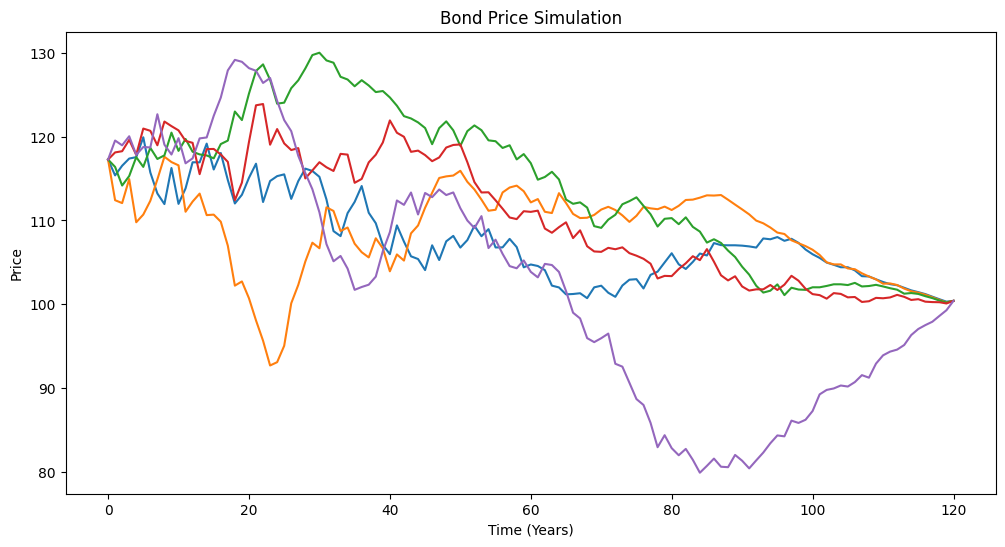

In [23]:
erk.bond_price(10, 100, 0.05, 12, rates[[1,2,3,4,5]]).plot(legend=None, figsize=(12,6), title='Bond Price Simulation', ylabel='Price', xlabel='Time (Years)')

In [25]:
prices = erk.bond_price(10, 100, 0.05, 12, rates[[1,2,3,4,5]])
prices

,1,2,3,4,5
0,117.260292,117.260292,117.260292,117.260292,117.260292
1,115.372989,112.415013,116.385309,118.111394,119.530066
2,116.524392,112.071322,114.165206,118.255793,118.958832
3,117.37936,114.936445,115.290626,119.610035,120.038414
4,117.547683,109.785997,117.548264,117.819476,117.832123
...,...,...,...,...,...
116,101.220892,101.150066,100.974082,100.319311,97.523282
117,100.91253,100.843097,100.744471,100.270892,97.92831
118,100.609369,100.519744,100.45191,100.25335,98.621632
119,100.319682,100.241943,100.218399,100.106366,99.299357


In [26]:
br = prices.pct_change().dropna()
erk.annualize_rets(br, 12)

C:\Users\user\AppData\Local\Temp\ipykernel_9524\3191967235.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  br = prices.pct_change().dropna()


1   -0.015387
2   -0.015387
3   -0.015387
4   -0.015387
5   -0.015387
dtype: float64

In [30]:
p = erk.bond_price(10, 100, 0.05, 12, rates[[1,2,3,4]])
btr = erk.bond_total_return(p, 100, 0.05, 12)
erk.annualize_rets(btr, 12)

<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


1    0.031359
2    0.031047
3    0.028963
4    0.030318
dtype: float64

In [32]:
prices_10 = erk.bond_price(10, 100, 0.05, 12, rates)
prices_10[[1,2,3]].tail()

,1,2,3
116,101.220892,101.150066,100.974082
117,100.912530,100.843097,100.744471
118,100.609369,100.519744,100.451910
119,100.319682,100.241943,100.218399
120,100.416667,100.416667,100.416667


In [33]:
prices_30 = erk.bond_price(30, 100, 0.05, 12, rates)
prices_30[[1,2,3]].tail()

,1,2,3
116,165.420641,160.399909,148.695958
117,164.837783,158.352296,149.660935
118,164.702077,152.458884,143.922961
119,168.763432,147.659934,141.914583
120,167.837181,146.495017,146.420037


In [34]:
prices_30[[1,2,3]].head()

,1,2,3
0,139.531564,139.531564,139.531564
1,134.871545,127.455672,137.491448
2,138.103434,126.782732,132.004052
3,140.642923,134.194468,135.113623
4,141.377112,121.549177,141.378692


In [35]:
rets_30= erk.bond_total_return(prices_30, 100, 0.05, 12)
rets_10= erk.bond_total_return(prices_10, 100, 0.05, 12)
rets_bonds= 0.6*rets_10 + 0.4*rets_30

<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4166666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>

In [37]:
mean_rets_bonds =rets_bonds.mean(axis="columns")
erk.summary_stats(pd.DataFrame(mean_rets_bonds))

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
0,0.035849,0.003405,0.017986,2.982763,-0.001334,-0.00099,1.671736,0.0


In [38]:
price_eq = erk.gbm(n_years=10, n_scenarios=500, mu=0.07, sigma=0.15)
price_eq.shape

(121, 500)